In [127]:
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

Saving employee_attrition_dataset.csv to employee_attrition_dataset.csv


In [170]:
df = pd.read_csv(next(iter(uploaded)))


In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [172]:
df.head()


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,64571,49,Male,25,Technology,12082,Excellent,High,Average,0,...,2,Senior,Medium,95.0,No,No,No,Good,High,Stayed
1,969,24,Male,1,Education,4270,Good,Medium,Average,0,...,3,Entry,Small,6.0,No,No,No,Good,High,Left
2,44926,52,Male,37,Technology,10498,Good,High,Below Average,4,...,3,Mid,Medium,79.0,Yes,No,Yes,Poor,Low,Stayed
3,74031,22,Male,12,Technology,8611,Good,Low,Average,0,...,4,Entry,Small,65.0,No,No,No,Poor,Low,Left
4,9777,29,Male,3,Education,3064,Poor,Low,Low,0,...,0,Entry,Medium,48.0,No,No,No,Excellent,Low,Left


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee ID                 15000 non-null  int64  
 1   Age                         15000 non-null  int64  
 2   Gender                      15000 non-null  object 
 3   Years at Company            15000 non-null  int64  
 4   Job Role                    15000 non-null  object 
 5   Monthly Income              15000 non-null  int64  
 6   Work-Life Balance           15000 non-null  object 
 7   Job Satisfaction            15000 non-null  object 
 8   Performance Rating          15000 non-null  object 
 9   Number of Promotions        15000 non-null  int64  
 10  Overtime                    15000 non-null  object 
 11  Distance from Home          15000 non-null  float64
 12  Education Level             15000 non-null  object 
 13  Marital Status              150

In [132]:
df.shape

(15000, 24)

In [174]:
df.isnull().sum()

,0
Employee ID,0
Age,0
Gender,0
Years at Company,0
Job Role,0
Monthly Income,0
Work-Life Balance,0
Job Satisfaction,0
Performance Rating,0
Number of Promotions,0


In [175]:
df.duplicated().sum()

np.int64(0)

In [176]:
df.dtypes

,0
Employee ID,int64
Age,int64
Gender,object
Years at Company,int64
Job Role,object
Monthly Income,int64
Work-Life Balance,object
Job Satisfaction,object
Performance Rating,object
Number of Promotions,int64


In [177]:
df['Attrition'].value_counts()

,count
Attrition,
Stayed,7878
Left,7122


In [178]:
df["Education Level"] = (
    df["Education Level"]
    .str.replace("â€™", "'", regex=False)
    .str.replace("’", "'", regex=False)
)

In [179]:
print(df["Education Level"].unique())

["Bachelor's Degree" 'High School' "Master's Degree" 'PhD'
 'Associate Degree']


In [180]:
df.drop(columns=["Employee ID"], inplace=True)

In [181]:
df.describe()

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure (In Months)
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.538000,15.744933,7361.907667,0.819400,50.324290,1.658400,55.607805
std,12.059541,11.198457,2553.227628,0.987682,28.167674,1.578272,24.984685
min,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,28.000000,7.000000,5686.000000,0.000000,26.000000,0.000000,36.000000
50%,39.000000,13.000000,7367.000000,0.000000,49.990839,1.000000,55.711899
75%,49.000000,23.000000,8887.000000,1.000000,75.000000,3.000000,75.000000
max,59.000000,51.000000,50030.000000,4.000000,99.000000,15.000000,127.000000


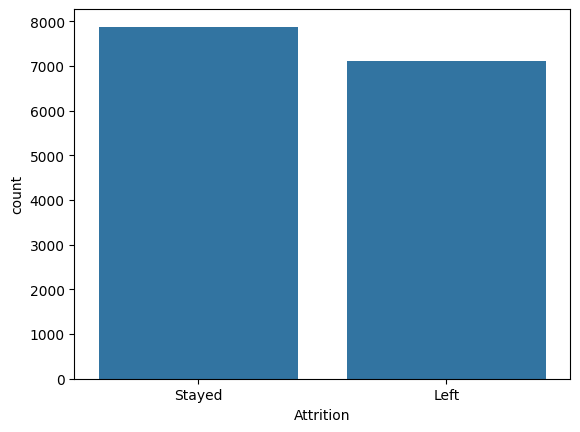

In [182]:
sns.countplot(x="Attrition", data=df)
plt.show()

In [183]:
from sklearn.preprocessing import LabelEncoder

# Features and target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# -----------------------------
# Encode target
# -----------------------------

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# -----------------------------
# Encode categorical columns
# -----------------------------

categorical_cols = X.select_dtypes(include="object").columns.tolist()

encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col].astype(str))
    encoders[col] = encoder

print("Categorical columns encoded:")
print(categorical_cols)

for col, encoder in encoders.items():
    print(f"{col}: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")



Categorical columns encoded:
['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']
Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Job Role: {'Education': np.int64(0), 'Finance': np.int64(1), 'Healthcare': np.int64(2), 'Media': np.int64(3), 'Technology': np.int64(4)}
Work-Life Balance: {'Excellent': np.int64(0), 'Fair': np.int64(1), 'Good': np.int64(2), 'Poor': np.int64(3)}
Job Satisfaction: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2), 'Very High': np.int64(3)}
Performance Rating: {'Average': np.int64(0), 'Below Average': np.int64(1), 'High': np.int64(2), 'Low': np.int64(3)}
Overtime: {'No': np.int64(0), 'Yes': np.int64(1)}
Education Level: {'Associate Degree': np.int64(0), "Bachelor's Degree": np.int64(1), 'High School': np.int64(2), "Ma

In [184]:
print("Number of features:", X.shape[1])
print("\nFeatures:")
for i, col in enumerate(X.columns, 1):
    print(i, col)

Number of features: 22

Features:
1 Age
2 Gender
3 Years at Company
4 Job Role
5 Monthly Income
6 Work-Life Balance
7 Job Satisfaction
8 Performance Rating
9 Number of Promotions
10 Overtime
11 Distance from Home
12 Education Level
13 Marital Status
14 Number of Dependents
15 Job Level
16 Company Size
17 Company Tenure (In Months)
18 Remote Work
19 Leadership Opportunities
20 Innovation Opportunities
21 Company Reputation
22 Employee Recognition


In [185]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (12000, 22)
X_test: (3000, 22)
y_train: (12000,)
y_test: (3000,)


In [186]:
### Feature Importance Analysis

In [187]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                       Feature  Importance
14                   Job Level    0.104777
10          Distance from Home    0.086227
4               Monthly Income    0.082429
12              Marital Status    0.079557
16  Company Tenure (In Months)    0.077434
2             Years at Company    0.071737
0                          Age    0.071682
17                 Remote Work    0.048665
13        Number of Dependents    0.043103
11             Education Level    0.041273
5            Work-Life Balance    0.040814
8         Number of Promotions    0.035023
3                     Job Role    0.032222
20          Company Reputation    0.031914
21        Employee Recognition    0.028887
6             Job Satisfaction    0.027697
7           Performance Rating    0.025683
15                Company Size    0.023990
1                       Gender    0.015910
9                     Overtime    0.014795
19    Innovation Opportunities    0.010583
18    Leadership Opportunities    0.005598


In [188]:
print("Total features:", X.shape[1])
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Total features: 22
Training shape: (12000, 22)
Testing shape: (3000, 22)


In [189]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# ============================================================
# MODEL DEFINITIONS
# ============================================================

models = {

    # Scaling is important for Logistic Regression
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    # Scaling is important for KNN
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    # Scaling is important for SVM
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=10,
            probability=True,
            random_state=42
        ))
    ]),

    # Tree-based models do not require scaling
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    # Naive Bayes does not require scaling for this comparison
    "Naive Bayes": GaussianNB()
}


# ============================================================
# MODEL TRAINING AND EVALUATION
# ============================================================

results = []

for name, model in models.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability / decision scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Print results
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })


# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON")

print(
    results_df
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)


Logistic Regression
Accuracy : 0.7043
Precision: 0.7176
Recall   : 0.7208
F1 Score : 0.7192
ROC-AUC  : 0.7774
KNN
Accuracy : 0.6693
Precision: 0.6884
Recall   : 0.677
F1 Score : 0.6827
ROC-AUC  : 0.7095
SVM
Accuracy : 0.691
Precision: 0.7087
Recall   : 0.6992
F1 Score : 0.7039
ROC-AUC  : 0.7726
Decision Tree
Accuracy : 0.6483
Precision: 0.6635
Recall   : 0.6707
F1 Score : 0.6671
ROC-AUC  : 0.6471
Random Forest
Accuracy : 0.7343
Precision: 0.7442
Recall   : 0.7532
F1 Score : 0.7487
ROC-AUC  : 0.8257
Naive Bayes
Accuracy : 0.6883
Precision: 0.7271
Recall   : 0.651
F1 Score : 0.687
ROC-AUC  : 0.7703

MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0        Random Forest  0.734333   0.744201  0.753173  0.748660  0.825691
1  Logistic Regression  0.704333   0.717625  0.720812  0.719215  0.777362
2                  SVM  0.691000   0.708682  0.699239  0.703928  0.772589
3          Naive Bayes  0.688333   0.727144  0.651015  0.686977  0.770330
4       

In [190]:
#tune Random Forest

In [191]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=15,          # reduced from 30
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Accuracy:")
print(random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15}

Best CV Accuracy:
0.7433333333333333


In [192]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

y_prob = best_rf.predict_proba(X_test)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Test Accuracy: 0.7353333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72      1424
           1       0.74      0.76      0.75      1576

    accuracy                           0.74      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.74      0.74      0.74      3000


Confusion Matrix:
[[1006  418]
 [ 376 1200]]

ROC-AUC: 0.8287884810072434


In [194]:
#HistGradientBoostingClassifier

In [193]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

hgb = HistGradientBoostingClassifier(
    random_state=42
)

param_grid = {
    'max_iter': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_leaf_nodes': [15, 20, 30, 40],
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [20, 30, 50, 70],
    'l2_regularization': [0, 0.1, 0.5, 1.0]
}

random_search_hgb = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_hgb.fit(X_train, y_train)

print("Best Parameters:")
print(random_search_hgb.best_params_)

print("\nBest CV Accuracy:")
print(random_search_hgb.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'min_samples_leaf': 30, 'max_leaf_nodes': 20, 'max_iter': 300, 'max_depth': 3, 'learning_rate': 0.1, 'l2_regularization': 0.5}

Best CV Accuracy:
0.7536666666666667


In [195]:
best_hgb = random_search_hgb.best_estimator_

y_pred_hgb = best_hgb.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Test Accuracy:", accuracy_score(y_test, y_pred_hgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_hgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_hgb))

y_prob_hgb = best_hgb.predict_proba(X_test)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_hgb))

Test Accuracy: 0.753

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1424
           1       0.77      0.76      0.76      1576

    accuracy                           0.75      3000
   macro avg       0.75      0.75      0.75      3000
weighted avg       0.75      0.75      0.75      3000


Confusion Matrix:
[[1054  370]
 [ 371 1205]]

ROC-AUC: 0.8439407118006046


In [156]:
#XGBoost

In [196]:
!pip install xgboost -q

In [197]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [2, 3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_xgb.fit(X_train, y_train)

print("Best Parameters:")
print(random_search_xgb.best_params_)

print("\nBest CV Accuracy:")
print(random_search_xgb.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}

Best CV Accuracy:
0.7575


In [198]:
best_xgb = random_search_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Test Accuracy: 0.758

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.75      0.75      1424
           1       0.77      0.76      0.77      1576

    accuracy                           0.76      3000
   macro avg       0.76      0.76      0.76      3000
weighted avg       0.76      0.76      0.76      3000


Confusion Matrix:
[[1070  354]
 [ 372 1204]]

ROC-AUC: 0.8460851055866081


In [199]:
print(target_encoder.classes_)

['Left' 'Stayed']


In [200]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Decision Tree",
        "Random Forest",
        "HistGradientBoosting",
        "XGBoost"
    ],
    "Accuracy": [
        0.7043,
        0.6693,
        0.6910,
        0.6483,
        0.7343,
        0.7530,
        0.7580
    ],
    "ROC-AUC": [
        0.7774,
        0.7095,
        0.7726,
        0.6471,
        0.8257,
        0.8439,
        0.8461
    ]
})

model_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,ROC-AUC
6,XGBoost,0.7580,0.8461
5,HistGradientBoosting,0.7530,0.8439
4,Random Forest,0.7343,0.8257
0,Logistic Regression,0.7043,0.7774
2,SVM,0.6910,0.7726
1,KNN,0.6693,0.7095
3,Decision Tree,0.6483,0.6471


In [201]:
import joblib

# Get the best XGBoost model
best_xgb = random_search_xgb.best_estimator_

# Save the model
joblib.dump(best_xgb, "employee_attrition_xgboost.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [202]:
feature_names = X_train.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

print("Feature names saved successfully!")
print(feature_names)

Feature names saved successfully!
['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure (In Months)', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']


In [203]:
import joblib

# Use the final XGBoost model
final_model = best_xgb

# Get the feature names used during training
feature_names = X_train.columns.tolist()

# Save everything required for Django prediction
model_data = {
    "model": final_model,
    "feature_names": feature_names,
    "encoders": encoders,
    "target_encoder": target_encoder
}

# Save the final model package
joblib.dump(
    model_data,
    "employee_attrition_model.pkl"
)

print("Final model saved successfully!")
print("Model type:", type(final_model).__name__)
print("Number of features:", len(feature_names))
print("Features:", feature_names)
print("Target classes:", target_encoder.classes_)

Final model saved successfully!
Model type: XGBClassifier
Number of features: 22
Features: ['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure (In Months)', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']
Target classes: ['Left' 'Stayed']


In [204]:
from google.colab import files

files.download("employee_attrition_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [166]:
#test prediction

In [206]:
# Test prediction using one sample from the test set

sample = X_test.iloc[[0]]

prediction_encoded = best_xgb.predict(sample)[0]
probabilities = best_xgb.predict_proba(sample)[0]

prediction_label = target_encoder.inverse_transform(
    [prediction_encoded]
)[0]

leave_probability = probabilities[0] * 100
stay_probability = probabilities[1] * 100

print("Prediction:", prediction_label)
print(f"Probability of Leaving: {leave_probability:.2f}%")
print(f"Probability of Staying: {stay_probability:.2f}%")

Prediction: Left
Probability of Leaving: 88.27%
Probability of Staying: 11.73%
